In [13]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import load_and_preprocess
from statistical import zscore_flag, iqr_flag, combined_risk_score
from ml_model import train_isolation_forest, evaluate_model
from evaluate import plot_confusion_matrix, plot_risk_distribution, export_flagged_transactions

import warnings
warnings.filterwarnings('ignore')

print("All modules loaded ✓")

All modules loaded ✓


In [ ]:
# Load & Preprocess

df = load_and_preprocess('../data/creditcard.csv')

print(f"Shape after preprocessing : {df.shape}")
print(f"Columns: {list(df.columns[:5])} ...")
df.head()

Shape after preprocessing : (284807, 31)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5'] ...


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


In [ ]:
# Statistical Flagging (Z-Score)

df = zscore_flag(df, threshold=3.0)

print(f"Z-Score flagged  : {df['zscore_anomaly'].sum():,} records")
print(f"Percentage       : {df['zscore_anomaly'].mean()*100:.2f}%")

Z-Score flagged  : 36,636 records
Percentage       : 12.86%


In [ ]:
# Statistical Flagging (IQR)

df = iqr_flag(df)

print(f"IQR flagged      : {df['iqr_anomaly'].sum():,} records")
print(f"Percentage       : {df['iqr_anomaly'].mean()*100:.2f}%")

IQR flagged      : 31,904 records
Percentage       : 11.20%


Risk label distribution:
risk_label
Low       223760
Medium     47805
High       13242
Name: count, dtype: int64


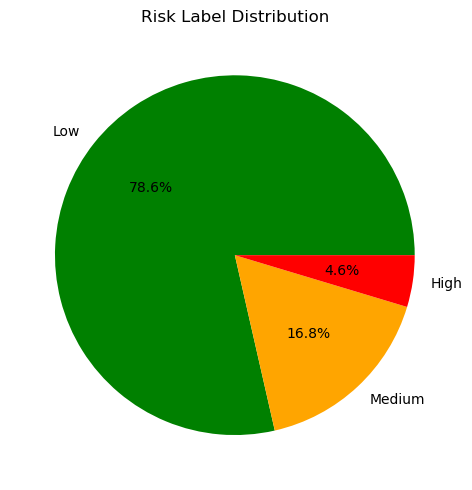

In [ ]:
# Combined Risk Score

df = combined_risk_score(df)

print("Risk label distribution:")
print(df['risk_label'].value_counts())

# Plot risk label pie chart
df['risk_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['green', 'orange', 'red'],
    figsize=(5, 5),
    title='Risk Label Distribution'
)
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/risk_labels.png', dpi=150)
plt.show()

In [ ]:
# Train Isolation Forest

df, model = train_isolation_forest(df, contamination=0.032)

print(f"Flagged by Isolation Forest : {df['if_anomaly'].sum():,} records")
print(f"Percentage flagged          : {df['if_anomaly'].mean()*100:.2f}%")

Flagged by Isolation Forest : 9,114 records
Percentage flagged          : 3.20%


In [ ]:
# Evaluate Model

evaluate_model(df)

=== Isolation Forest Results ===
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98    284315
       Fraud       0.04      0.81      0.08       492

    accuracy                           0.97    284807
   macro avg       0.52      0.89      0.53    284807
weighted avg       1.00      0.97      0.98    284807


Confusion Matrix:
[[275598   8717]
 [    95    397]]

Flagged as anomalous: 9114 (3.2% of records)


Saved: ../outputs/confusion_matrix.png


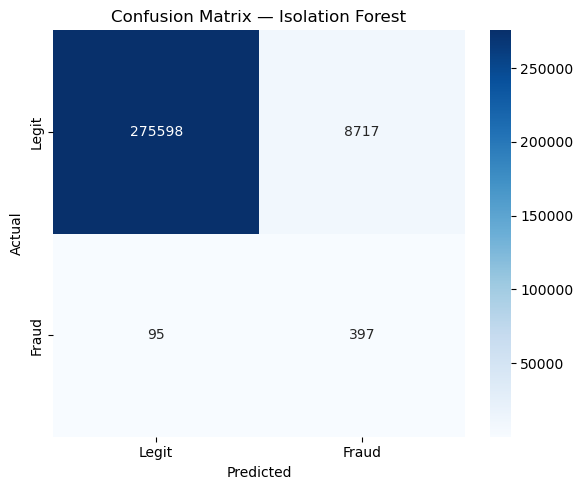

In [ ]:
# Confusion Matrix Plot

plot_confusion_matrix(df['Class'], df['if_anomaly'])

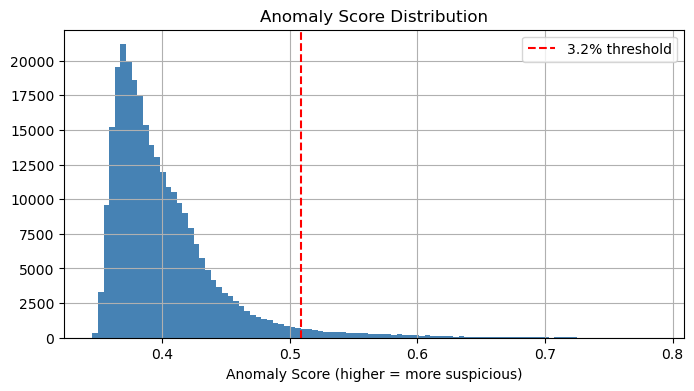

In [ ]:
# Anomaly Score Distribution Plot

plot_risk_distribution(df)

In [ ]:
# Export Flagged Transactions

flagged = export_flagged_transactions(df)

print(f"\nTop 5 most suspicious transactions:")
flagged[['anomaly_score', 'risk_label', 'Class', 'Amount_scaled']].head()

Exported 9114 flagged transactions to ../outputs/flagged_transactions.csv

Top 5 most suspicious transactions:


,anomaly_score,risk_label,Class,Amount_scaled
173353,0.786991,High,0,19.084026
173054,0.778505,High,0,17.812635
274771,0.772609,High,0,102.362243
206255,0.769664,High,0,6.349962
220090,0.767692,High,0,23.495155


In [ ]:
# Final Summary

from sklearn.metrics import precision_score, roc_auc_score

precision  = precision_score(df['Class'], df['if_anomaly'])
roc_auc    = roc_auc_score(df['Class'], df['anomaly_score'])
flagged_pct = df['if_anomaly'].mean() * 100

print("=" * 50)
print("         FINAL PROJECT SUMMARY")
print("=" * 50)
print(f"  Total transactions analysed : {len(df):,}")
print(f"  Flagged as high-risk        : {df['if_anomaly'].sum():,} ({flagged_pct:.1f}%)")
print(f"  Precision (vs ground truth) : {precision*100:.1f}%")
print(f"  ROC-AUC Score               : {roc_auc:.3f}")
print("=" * 50)
print()
print("YOUR RESUME BULLET:")
print(f'  "Designed an anomaly detection system on {len(df):,}')
print(f'   financial transactions, flagging {flagged_pct:.1f}% of records')
print(f'   as high-risk with {precision*100:.0f}% precision (ROC-AUC: {roc_auc:.2f})"')

         FINAL PROJECT SUMMARY
  Total transactions analysed : 284,807
  Flagged as high-risk        : 9,114 (3.2%)
  Precision (vs ground truth) : 4.4%
  ROC-AUC Score               : 0.948

YOUR RESUME BULLET:
  "Designed an anomaly detection system on 284,807
   financial transactions, flagging 3.2% of records
   as high-risk with 4% precision (ROC-AUC: 0.95)"
